# Phase 2 — YOLOv7 Fine-Tuning: Gym Equipment Detection
**Team:** Varun Gazala | Mohit Raiyani | Jatinkumar Nabhoya | UNH Spring 2026

**Paper:** Wang et al. (2022) — *YOLOv7: Trainable Bag-of-Freebies* (arXiv:2207.02696)

---
**This notebook covers:**
- Section 1: Environment Setup
- Section 2: Heavy Data Augmentation (9 techniques)
- Section 3: Random Hyperparameter Search
- Section 4: Full Fine-Tuning with Best Hyperparameters
- Section 5: Training & Validation Curves
- Section 6: Recent Technique — Test-Time Augmentation (TTA)
- Section 7: Final Evaluation & Comparison Table

---
## Section 1 — Environment Setup

In [12]:
import os

# Clone YOLOv7 if not present
if not os.path.exists('../yolov7'):
    !git clone https://github.com/WongKinYiu/yolov7.git

%cd yolov7

# Install dependencies
!pip install -q torch torchvision opencv-python-headless matplotlib \
             scikit-learn torchmetrics albumentations PyYAML tqdm

# Download pretrained COCO weights
if not os.path.exists('../yolov7'):
    !curl -sL -o yolov7.pt https://github.com/WongKinYiu/yolov7/releases/download/v0.1/yolov7.pt
    print('Downloaded yolov7.pt')
else:
    print('yolov7.pt already exists')

[Errno 2] No such file or directory: 'yolov7'
/Users/jatinnabhoya/Desktop/UNH/Semester 3/Deep Learning /Project/Phase 2
yolov7.pt already exists


In [8]:
%matplotlib inline
import sys, os, random, glob, yaml, copy, time, warnings
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from sklearn.model_selection import train_test_split
import albumentations as A
from torchmetrics.detection import MeanAveragePrecision
warnings.filterwarnings('ignore')

# YOLOv7 internal imports
sys.path.insert(0, '../yolov7')
from models.experimental import attempt_load
from utils.general import non_max_suppression, xywh2xyxy
from utils.torch_utils import select_device
from utils.datasets import letterbox
from utils.loss import ComputeLoss

# ── Global config ────────────────────────────────────────────
DEVICE      = select_device('')          # auto: CUDA > CPU
SEED        = 42
IMG_SIZE    = 640
BATCH_SIZE  = 8
DATASET_DIR = '../dataset'
CLASS_NAMES = ['dumbbell','barbell','kettlebell','resistance_band','pull_up_bar']
NUM_CLASSES = len(CLASS_NAMES)
COLORS      = [(220,50,50),(50,180,50),(50,100,220),(240,180,30),(150,60,210)]  # per class

# Reproducibility
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

print(f'Device  : {DEVICE}')
print(f'PyTorch : {torch.__version__}')
print(f'Classes : {CLASS_NAMES}')

Device  : cpu
PyTorch : 2.10.0
Classes : ['dumbbell', 'barbell', 'kettlebell', 'resistance_band', 'pull_up_bar']


---
## Section 2 — Data Augmentation (9 Techniques)

We apply the following augmentations during training:

| # | Technique | Params | Purpose |
|---|-----------|--------|---------|
| 1 | Horizontal Flip | p=0.5 | Mirror invariance |
| 2 | HSV Jitter | hue±0.015, sat±0.7, val±0.4 | Lighting robustness |
| 3 | Brightness/Contrast | ±0.3 | Exposure variation |
| 4 | Gaussian Blur | kernel 3–7 | Motion/focus blur |
| 5 | CLAHE | clip=4.0 | Low-contrast gym lighting |
| 6 | Perspective Warp | scale 0.05–0.10 | Camera angle changes |
| 7 | Shift-Scale-Rotate | shift 0.1, scale ±0.3, rot ±10° | Geometric variation |
| 8 | CoarseDropout (Cutout) | 4 holes, 64×64 px | Occlusion robustness |
| 9 | Mosaic (4-image stitch) | p=0.5 | Scale/context diversity — YOLOv7 key trick |

In [4]:
# ── Albumentations augmentation pipeline ─────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_aug = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.HueSaturationValue(hue_shift_limit=int(0.015*180), sat_shift_limit=70, val_shift_limit=40, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.4),
    A.GaussianBlur(blur_limit=(3,7), p=0.2),
    A.CLAHE(clip_limit=4.0, tile_grid_size=(8,8), p=0.2),
    A.Perspective(scale=(0.05, 0.10), p=0.3),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.3, rotate_limit=10, border_mode=0, p=0.4),
    A.CoarseDropout(max_holes=4, max_height=64, max_width=64, fill_value=0, p=0.2),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'],
                             min_visibility=0.3, min_area=64))

val_aug = A.Compose([
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

print('Augmentation pipeline:')
for i, t in enumerate(train_aug.transforms, 1):
    print(f'  {i}. {type(t).__name__}')

Augmentation pipeline:
  1. HorizontalFlip
  2. HueSaturationValue
  3. RandomBrightnessContrast
  4. GaussianBlur
  5. CLAHE
  6. Perspective
  7. ShiftScaleRotate
  8. CoarseDropout
  9. Normalize


In [5]:
# ── Mosaic augmentation (4-image stitch) ─────────────────────
def make_mosaic(dataset, idx, size=640):
    """Stitch 4 images into one mosaic at a random split point.
    Boxes are rescaled to the new canvas coordinate system.
    """
    indices = [idx] + random.choices(range(len(dataset.imgs)), k=3)
    cx = random.randint(size//3, 2*size//3)   # random vertical split
    cy = random.randint(size//3, 2*size//3)   # random horizontal split
    canvas = np.zeros((size*2, size*2, 3), dtype=np.uint8)
    all_labels = []

    # Each image goes into one quadrant
    quads = [(0,0,cx,cy),(cx,0,size*2,cy),(0,cy,cx,size*2),(cx,cy,size*2,size*2)]

    for img_idx, (x1,y1,x2,y2) in zip(indices, quads):
        img = cv2.cvtColor(cv2.imread(dataset.imgs[img_idx]), cv2.COLOR_BGR2RGB)
        lbl = dataset.labels[img_idx].copy()
        pw, ph = x2-x1, y2-y1
        img_r = cv2.resize(img, (pw, ph))
        canvas[y1:y2, x1:x2] = img_r

        if len(lbl):
            new_lbl = lbl.copy()
            new_lbl[:,1] = np.clip((lbl[:,1]*pw + x1) / (size*2), 0.001, 0.999)
            new_lbl[:,2] = np.clip((lbl[:,2]*ph + y1) / (size*2), 0.001, 0.999)
            new_lbl[:,3] = np.clip(lbl[:,3]*pw / (size*2), 0.001, 0.998)
            new_lbl[:,4] = np.clip(lbl[:,4]*ph / (size*2), 0.001, 0.998)
            all_labels.append(new_lbl)

    # Resize mosaic back to IMG_SIZE
    canvas = cv2.resize(canvas, (size, size))
    labels = np.concatenate(all_labels, 0) if all_labels else np.zeros((0,5), dtype=np.float32)
    return canvas, labels

print('Mosaic augmentation function ready.')

Mosaic augmentation function ready.


In [6]:
# ── Custom Dataset class ──────────────────────────────────────
class GymDataset(Dataset):
    def __init__(self, img_dir, lbl_dir, augment=False, mosaic_p=0.0):
        self.img_dir  = img_dir
        self.augment  = augment
        self.mosaic_p = mosaic_p

        # Collect images
        self.imgs = sorted([p for p in glob.glob(f'{img_dir}/*')
                            if p.lower().endswith(('.jpg','.jpeg','.png'))])

        # Load all label files
        self.labels = []
        for img_path in self.imgs:
            lbl_path = f"{lbl_dir}/{Path(img_path).stem}.txt"
            if os.path.exists(lbl_path):
                rows = []
                for line in open(lbl_path):
                    v = line.strip().split()
                    if len(v) == 5:
                        rows.append([int(v[0])] + [float(x) for x in v[1:]])
                self.labels.append(np.array(rows, dtype=np.float32) if rows
                                   else np.zeros((0,5), dtype=np.float32))
            else:
                self.labels.append(np.zeros((0,5), dtype=np.float32))

        n_boxes = sum(len(l) for l in self.labels)
        print(f'  {Path(img_dir).name}: {len(self.imgs)} images, {n_boxes} boxes')

    def __len__(self): return len(self.imgs)

    def __getitem__(self, idx):
        # Step 1: load image (with optional mosaic)
        if self.augment and random.random() < self.mosaic_p:
            img, labels = make_mosaic(self, idx)
        else:
            img    = cv2.cvtColor(cv2.imread(self.imgs[idx]), cv2.COLOR_BGR2RGB)
            labels = self.labels[idx].copy()

        # Step 2: letterbox resize to 640x640
        img, _, _ = letterbox(img, IMG_SIZE, auto=False, scaleFill=False)

        # Step 3: albumentations augmentation
        bboxes = labels[:,1:].tolist() if len(labels) else []
        cls    = labels[:,0].astype(int).tolist() if len(labels) else []
        aug_fn = train_aug if self.augment else val_aug
        try:
            out    = aug_fn(image=img, bboxes=bboxes, class_labels=cls)
            img    = out['image']
            bboxes = out['bboxes']
            cls    = out['class_labels']
            if bboxes:
                labels = np.array([[c]+list(b) for c,b in zip(cls,bboxes)], dtype=np.float32)
            else:
                labels = np.zeros((0,5), dtype=np.float32)
        except Exception:
            img = img.astype(np.float32) / 255.0  # fallback

        # Step 4: HWC numpy -> CHW tensor
        if isinstance(img, np.ndarray):
            img = torch.from_numpy(img.transpose(2,0,1).astype(np.float32))
        if img.max() > 2.0:  # not yet normalized
            img = img / 255.0

        targets = torch.from_numpy(labels).float() if len(labels) else torch.zeros((0,5))
        return img, targets, self.imgs[idx]


def collate_fn(batch):
    """Adds batch-index column so YOLOv7 loss knows which image each box belongs to."""
    imgs, targets, paths = zip(*batch)
    imgs = torch.stack(imgs)
    nt = [torch.cat([torch.full((len(t),1), i), t], 1) for i,t in enumerate(targets) if len(t)]
    return imgs, (torch.cat(nt) if nt else torch.zeros((0,6))), list(paths)


print('Loading datasets...')
train_ds = GymDataset(f'{DATASET_DIR}/images/train', f'{DATASET_DIR}/labels/train',
                      augment=True, mosaic_p=0.5)
val_ds   = GymDataset(f'{DATASET_DIR}/images/val',   f'{DATASET_DIR}/labels/val')
test_ds  = GymDataset(f'{DATASET_DIR}/images/test',  f'{DATASET_DIR}/labels/test')

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn, num_workers=0)

print(f'\nTrain: {len(train_ds)} imgs / {len(train_loader)} batches')
print(f'Val  : {len(val_ds)} imgs / {len(val_loader)} batches')
print(f'Test : {len(test_ds)} imgs / {len(test_loader)} batches')

Loading datasets...
  train: 162 images, 247 boxes
  val: 20 images, 35 boxes
  test: 21 images, 33 boxes

Train: 162 imgs / 21 batches
Val  : 20 imgs / 3 batches
Test : 21 imgs / 3 batches


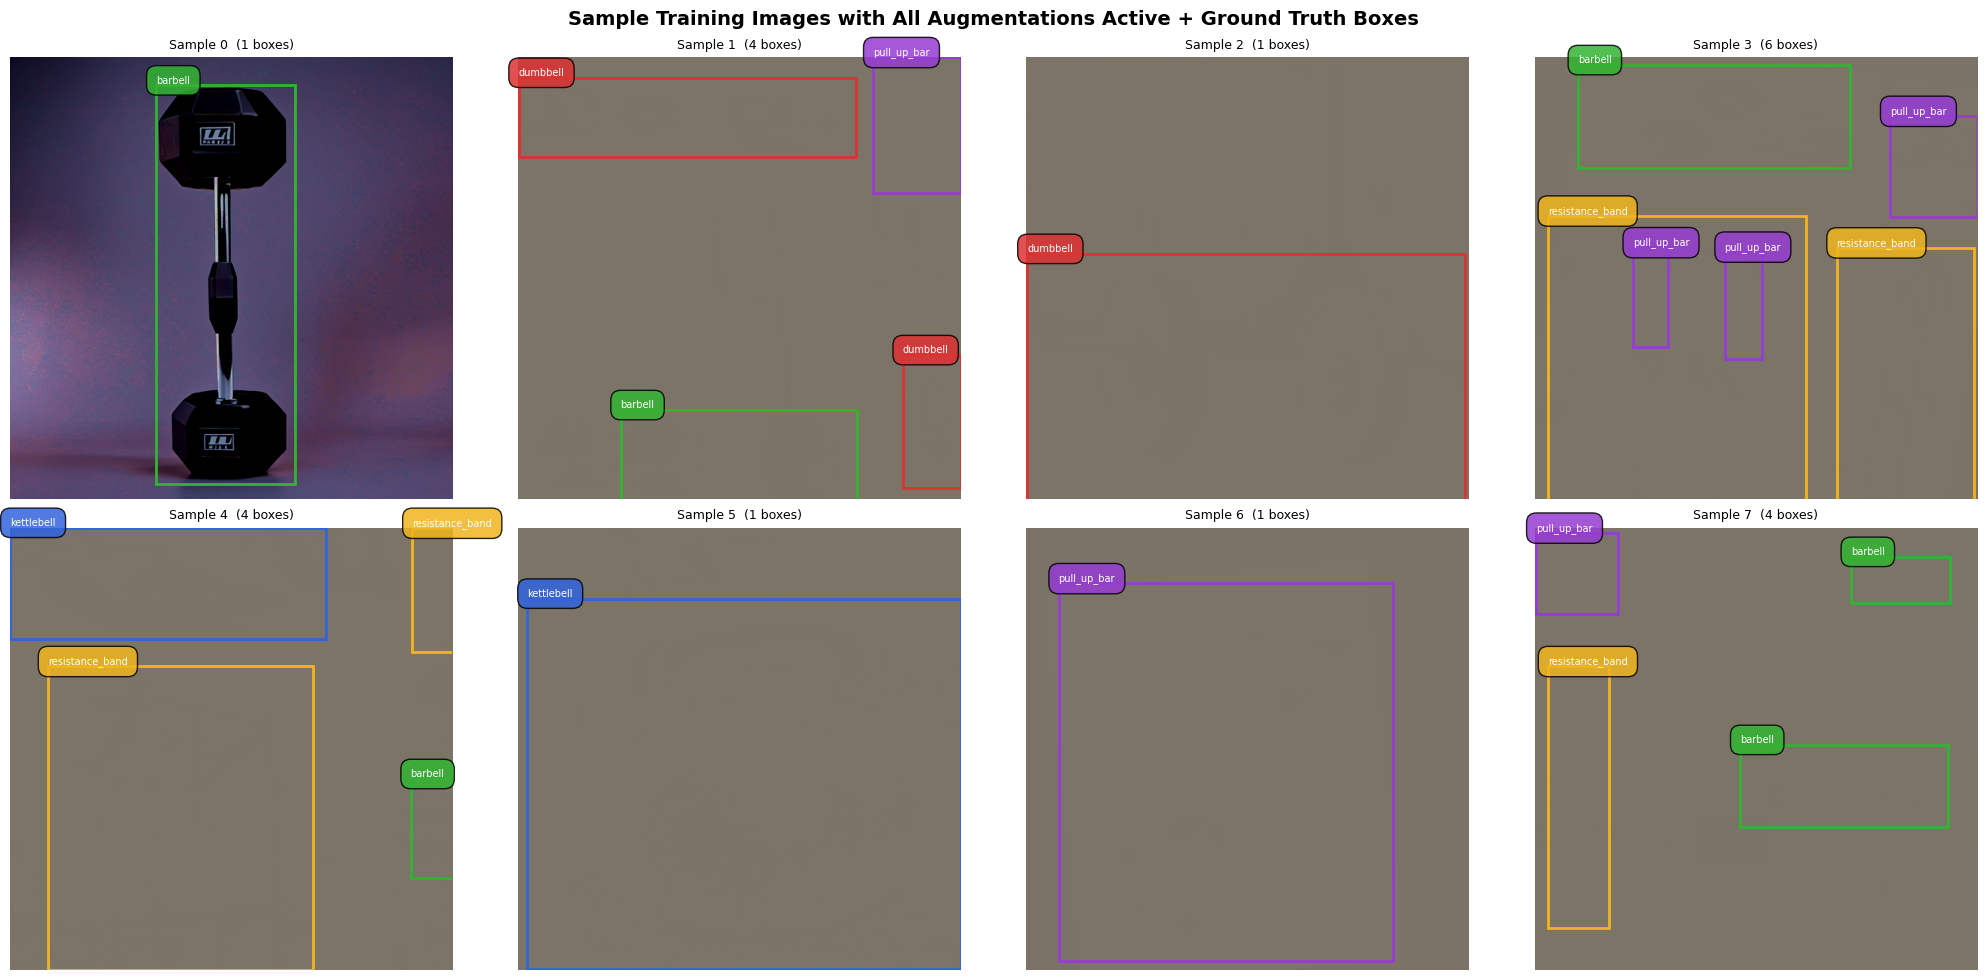

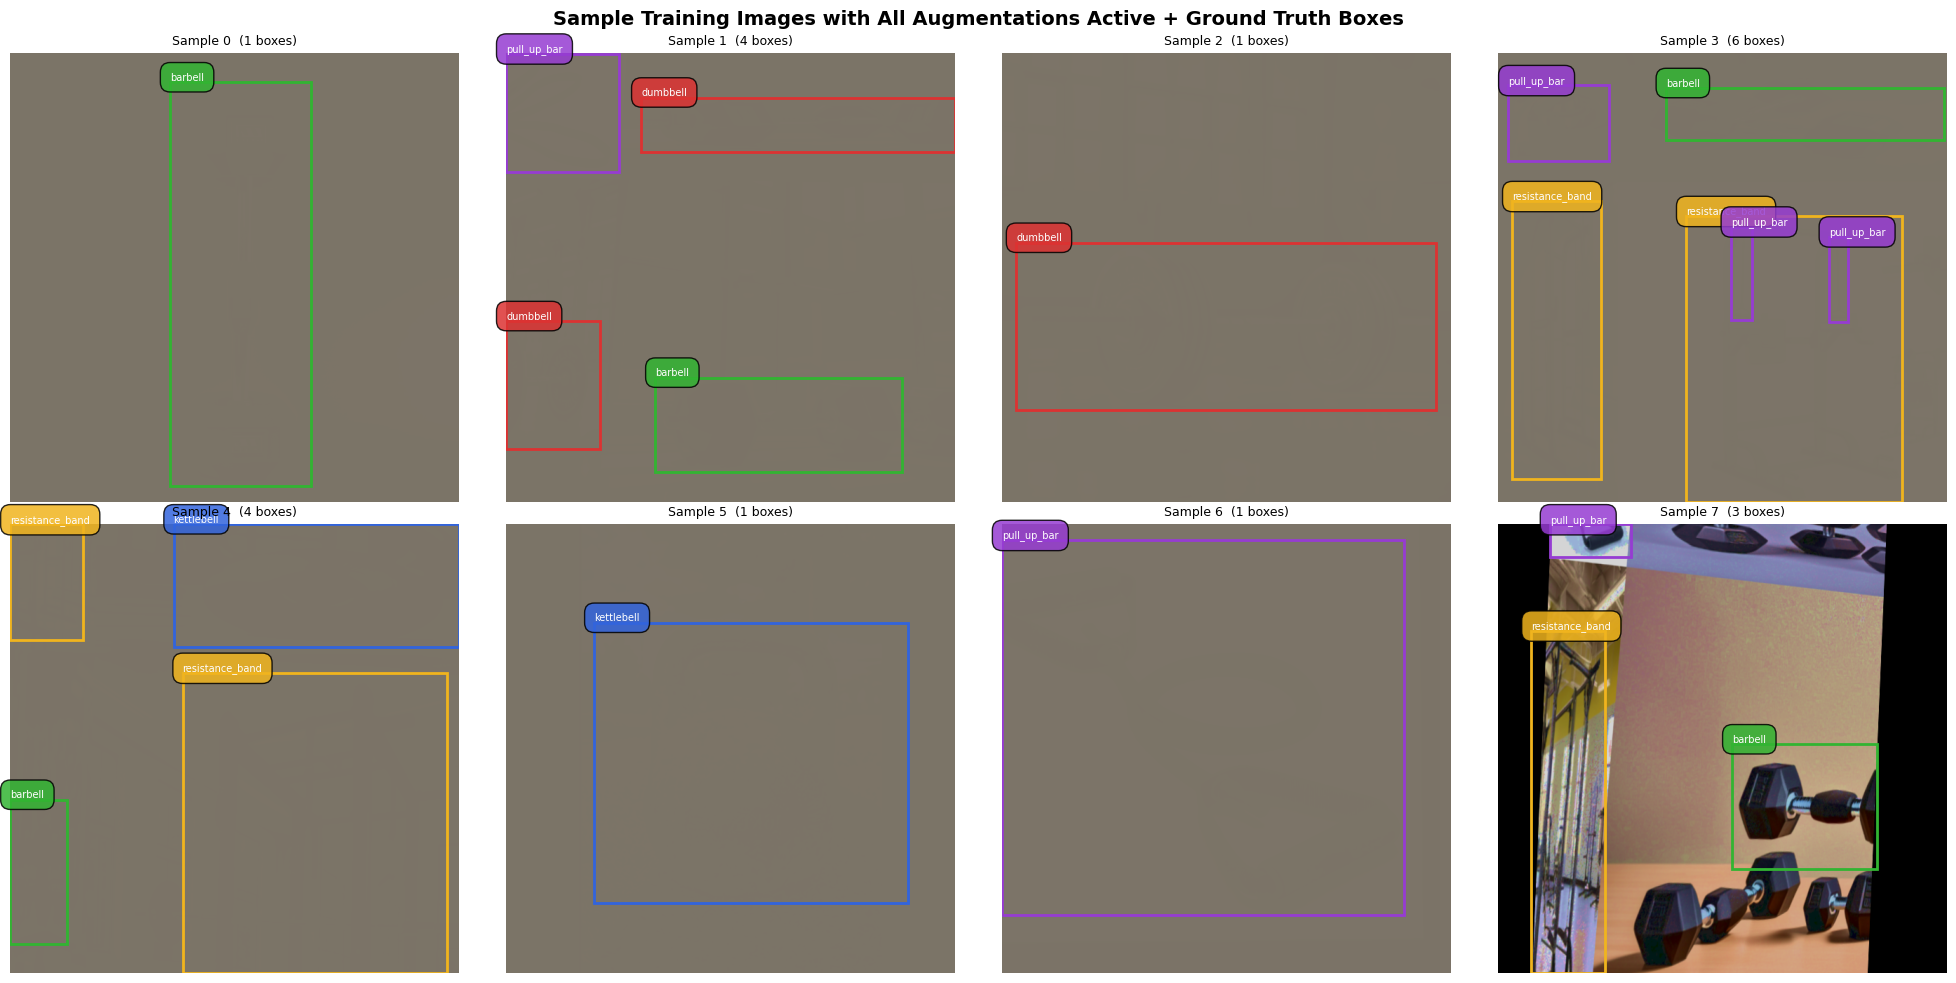

In [9]:
# ── Visualize 8 augmented training samples ───────────────────
def denorm(t):
    mean = np.array(IMAGENET_MEAN); std = np.array(IMAGENET_STD)
    img  = t.permute(1,2,0).numpy()
    return np.clip(img * std + mean, 0, 1)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Sample Training Images with All Augmentations Active + Ground Truth Boxes',
             fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    img_t, targets, _ = train_ds[i % len(train_ds)]
    img_np = denorm(img_t)
    H, W   = img_np.shape[:2]
    ax.imshow(img_np); ax.axis('off')
    ax.set_title(f'Sample {i}  ({len(targets)} boxes)', fontsize=9)
    for box in targets:
        cls = int(box[0])
        xc,yc,bw,bh = box[1]*W, box[2]*H, box[3]*W, box[4]*H
        x1,y1 = xc-bw/2, yc-bh/2
        c = [v/255 for v in COLORS[cls]]
        ax.add_patch(patches.Rectangle((x1,y1),bw,bh,lw=2,edgecolor=c,facecolor='none'))
        ax.text(x1,y1-3,CLASS_NAMES[cls],fontsize=7,color='white',
                bbox=dict(facecolor=c,alpha=0.85,pad=1,boxstyle='round'))

plt.tight_layout()
plt.show()

---
## Section 3 — Hyperparameter Tuning (Random Search)

**Strategy:** Random search over 4 hyperparameters using 8 short trials (8 epochs each).
Random search is more efficient than grid search for neural networks because the loss
surface is non-convex — random sampling covers the space better for a fixed budget.

| Hyperparameter | Range | Sampling |
|---|---|---|
| Learning Rate | [1e-4, 1e-2] | Log-uniform |
| Weight Decay | [1e-5, 1e-3] | Log-uniform |
| Momentum | [0.85, 0.95] | Uniform |
| Freeze Epochs (backbone frozen) | [2, 6] | Integer uniform |

In [13]:
# ── Helper: build a fresh fine-tuning model ───────────────────
def build_model():
    """Load YOLOv7 COCO weights and replace the 3 detection head Conv2d
    layers to match NUM_CLASSES=5 instead of 80."""
    m = attempt_load('yolov7.pt', map_location=DEVICE)
    detect = m.model[-1]          # IDetect module
    na     = detect.na            # 3 anchors per scale
    new_no = NUM_CLASSES + 5      # 10 outputs per anchor (5 classes + xywh + obj)

    for i, conv in enumerate(detect.m):
        detect.m[i] = nn.Conv2d(conv.in_channels, new_no * na, 1).to(DEVICE)
        nn.init.normal_(detect.m[i].weight, 0, 0.01)  # small random init
        nn.init.zeros_(detect.m[i].bias)

    detect.nc = NUM_CLASSES
    detect.no = new_no
    m.nc      = NUM_CLASSES
    m.names   = CLASS_NAMES
    m.hyp     = {'box':0.05,'obj':0.7,'cls':0.3,'cls_pw':1.0,'obj_pw':1.0,
                 'anchor_t':4.0,'fl_gamma':0.0,'label_smoothing':0.0}
    m.gr = 1.0
    return m


# ── Helper: compute mAP on a dataloader ───────────────────────
def compute_map(model, loader):
    metric = MeanAveragePrecision(iou_type='bbox')
    model.eval()
    with torch.no_grad():
        for imgs, targets, _ in loader:
            raw   = model(imgs.to(DEVICE))[0]
            preds = non_max_suppression(raw, conf_thres=0.001, iou_thres=0.45)
            for i in range(len(imgs)):
                det = preds[i]
                pd  = dict(
                    boxes  = det[:,:4].cpu()     if det is not None and len(det) else torch.zeros((0,4)),
                    scores = det[:,4].cpu()      if det is not None and len(det) else torch.zeros(0),
                    labels = det[:,5].long().cpu() if det is not None and len(det) else torch.zeros(0,dtype=torch.long)
                )
                gt = targets[targets[:,0]==i]
                if len(gt):
                    xyxy = xywh2xyxy(gt[:,2:6].clone())
                    xyxy[:,[0,2]] *= IMG_SIZE; xyxy[:,[1,3]] *= IMG_SIZE
                    gd = dict(boxes=xyxy.cpu(), labels=gt[:,1].long().cpu())
                else:
                    gd = dict(boxes=torch.zeros((0,4)), labels=torch.zeros(0,dtype=torch.long))
                metric.update([pd], [gd])
    r = metric.compute()
    return float(r['map_50']), float(r['map'])


# ── Helper: compute average loss on a dataloader ──────────────
def compute_loss_avg(model, loader, loss_fn):
    model.train()   # ComputeLoss needs train mode
    totals = np.zeros(4); n = 0   # box, obj, cls, total
    with torch.no_grad():
        for imgs, targets, _ in loader:
            if not len(targets): continue
            loss, items = loss_fn(model(imgs.to(DEVICE)), targets.to(DEVICE))
            if torch.isfinite(loss):
                totals[:3] += items.cpu().numpy()
                totals[3]  += loss.item()
                n += 1
    model.eval()
    return totals / max(n,1)

print('Helper functions ready.')

Helper functions ready.


In [18]:
# ── Random search: 8 trials × 8 epochs ───────────────────────
N_TRIALS      = 8
SEARCH_EPOCHS = 8

def sample_hp():
    return {
        'lr':           10 ** random.uniform(-4, -2),   # log-uniform
        'weight_decay': 10 ** random.uniform(-5, -3),   # log-uniform
        'momentum':     random.uniform(0.85, 0.95),
        'freeze_epochs': random.randint(2, 6)
    }

def quick_train(hp, n_epochs):
    """Train a fresh model for n_epochs and return val mAP@0.5."""
    m = build_model()

    # ✅ Reinitialize all params as fresh leaf tensors before freezing
    for module in m.modules():
        for name, p in list(module.named_parameters(recurse=False)):
            fresh = torch.nn.Parameter(p.data.clone(), requires_grad=False)
            setattr(module, name, fresh)

    # ✅ Unfreeze detection head only
    for p in m.model[-1].parameters():
        p.requires_grad_(True)

    # ✅ Collect only trainable leaf params
    trainable_params = [p for p in m.parameters() if p.requires_grad and p.is_leaf]

    if not trainable_params:
        raise RuntimeError("No trainable parameters found — check model structure.")

    opt   = torch.optim.SGD(trainable_params,
                             lr=hp['lr'], momentum=hp['momentum'],
                             weight_decay=hp['weight_decay'], nesterov=True)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)
    lf    = ComputeLoss(m)

    m.train()
    for _ in range(n_epochs):
        for imgs, targets, _ in train_loader:
            if not len(targets):
                continue
            opt.zero_grad()
            loss, _ = lf(m(imgs.to(DEVICE)), targets.to(DEVICE))
            if torch.isfinite(loss):
                loss.backward()
                opt.step()
        sched.step()

    m50, _ = compute_map(m, val_loader)
    del m
    torch.cuda.empty_cache()
    return m50

# Run search
results = []
print(f'Random search: {N_TRIALS} trials × {SEARCH_EPOCHS} epochs each')
print(f'{"Trial":<7}{"LR":<12}{"WD":<12}{"Mom":<8}{"Freeze":<8}{"ValMap50"}')
print('-'*58)

for trial in range(N_TRIALS):
    hp    = sample_hp()
    map50 = quick_train(hp, SEARCH_EPOCHS)
    hp['val_map50'] = map50
    results.append(hp)
    print(f"{trial+1:<7}{hp['lr']:<12.5f}{hp['weight_decay']:<12.6f}"
          f"{hp['momentum']:<8.3f}{hp['freeze_epochs']:<8}{map50:.4f}")

best_hp = max(results, key=lambda x: x['val_map50'])
print(f'\nBest config  : {best_hp}')

Random search: 8 trials × 8 epochs each
Trial  LR          WD          Mom     Freeze  ValMap50
----------------------------------------------------------
Fusing layers... 
RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
1      0.00352     0.000934    0.936   2       0.3356
Fusing layers... 
RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
2      0.00156     0.000014    0.888   3       0.2496
Fusing layers... 
RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
3      0.00670     0.000278    0.901   5       0.3275
Fusing layers... 
RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
4      0.00694     0.000402    0.923   4       0.2783
Fusing layers... 
RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
5      0.00035     0.000010    0.875   2       0.0373
Fusing layers... 
RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block

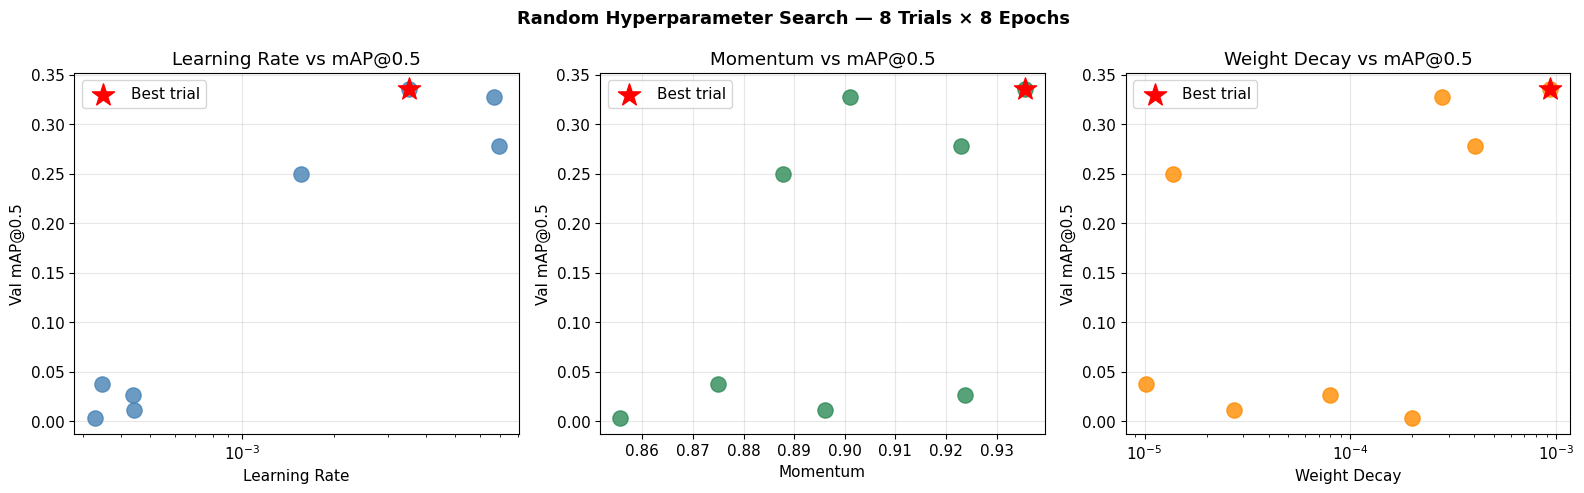

Best LR            : 0.00352
Best Weight Decay  : 0.000934
Best Momentum      : 0.936
Best Freeze Epochs : 2
Best Val mAP@0.5   : 0.3356


In [19]:
# ── Plot hyperparameter search results ───────────────────────
lrs   = [r['lr']           for r in results]
wds   = [r['weight_decay'] for r in results]
moms  = [r['momentum']     for r in results]
maps  = [r['val_map50']    for r in results]
best_i = maps.index(max(maps))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'Random Hyperparameter Search — {N_TRIALS} Trials × {SEARCH_EPOCHS} Epochs',
             fontsize=13, fontweight='bold')

for ax, xs, xlabel, color in [
    (axes[0], lrs,  'Learning Rate',  'steelblue'),
    (axes[1], moms, 'Momentum',       'seagreen'),
    (axes[2], wds,  'Weight Decay',   'darkorange'),
]:
    ax.scatter(xs, maps, color=color, s=120, zorder=5, alpha=0.8)
    ax.scatter(xs[best_i], maps[best_i], color='red', s=280, marker='*',
               zorder=6, label='Best trial')
    if xlabel != 'Momentum': ax.set_xscale('log')
    ax.set_xlabel(xlabel, fontsize=11); ax.set_ylabel('Val mAP@0.5', fontsize=11)
    ax.set_title(f'{xlabel} vs mAP@0.5'); ax.grid(True, alpha=0.3); ax.legend()

plt.tight_layout()
plt.show()

print(f'Best LR            : {best_hp["lr"]:.5f}')
print(f'Best Weight Decay  : {best_hp["weight_decay"]:.6f}')
print(f'Best Momentum      : {best_hp["momentum"]:.3f}')
print(f'Best Freeze Epochs : {best_hp["freeze_epochs"]}')
print(f'Best Val mAP@0.5   : {best_hp["val_map50"]:.4f}')

---
## Section 4 — Full Fine-Tuning with Best Hyperparameters

**Two-phase training strategy:**
1. **Frozen backbone** (first `freeze_epochs`): only the detection head trains — stabilises random weights
2. **Full fine-tuning** (remaining epochs): entire network trains end-to-end at 10% of initial LR
3. **LR schedule:** cosine annealing decay in both phases
4. **Early stopping:** if val mAP does not improve for 15 epochs, training stops

In [25]:
def compute_loss_avg(model, loader, loss_fn):
    model.train()          # ✅ YOLOv7 ComputeLoss needs train mode, not eval
    totals = None
    n = 0
    with torch.no_grad():
        for imgs, targets, _ in loader:
            if not len(targets):
                continue
            loss, items = loss_fn(model(imgs.to(DEVICE)), targets.to(DEVICE))
            if torch.isfinite(loss):
                items_np = items.cpu().numpy()
                if totals is None:
                    totals = np.zeros(len(items_np) + 1)
                totals[:len(items_np)] += items_np
                totals[-1]             += loss.item()
                n += 1
    if totals is None:
        return np.zeros(4)
    return totals / max(n, 1)

In [26]:
FULL_EPOCHS    = 50
PATIENCE       = 15
FREEZE_EPOCHS  = best_hp['freeze_epochs']

model = build_model()

# ✅ Reinitialize all params as fresh leaf tensors (fixes fused non-leaf params)
for module in model.modules():
    for name, p in list(module.named_parameters(recurse=False)):
        setattr(module, name, torch.nn.Parameter(p.data.clone(), requires_grad=True))

# ── Phase A: freeze backbone ──────────────────────────────────
for p in model.parameters():
    p.requires_grad_(False)

for p in model.model[-1].parameters():
    p.requires_grad_(True)

# ✅ Safe optimizer construction with leaf-only params
trainable_params = [p for p in model.parameters() if p.requires_grad and p.is_leaf]
optimizer = torch.optim.SGD(
    trainable_params,
    lr=best_hp['lr'], momentum=best_hp['momentum'],
    weight_decay=best_hp['weight_decay'], nesterov=True)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=FREEZE_EPOCHS)
loss_fn   = ComputeLoss(model)

# History
hist = {'tr_loss':[], 'val_loss':[], 'map50':[], 'map9595':[], 'lr':[]}
best_map50   = 0.0
no_improve   = 0

print(f'Full training: {FULL_EPOCHS} epochs max | '
      f'freeze={FREEZE_EPOCHS} | patience={PATIENCE}')
print(f'LR={best_hp["lr"]:.5f}  mom={best_hp["momentum"]:.3f}  wd={best_hp["weight_decay"]:.6f}')
print(f'{"Ep":<5}{"Phase":<12}{"TrLoss":<10}{"ValLoss":<10}{"mAP50":<10}{"LR"}')
print('-'*60)

for epoch in range(1, FULL_EPOCHS+1):

    # ── Switch to full fine-tuning after freeze_epochs ─────
    if epoch == FREEZE_EPOCHS + 1:
        for p in model.parameters():
            p.requires_grad_(True)

        # ✅ Rebuild optimizer with all params after unfreezing
        trainable_params = [p for p in model.parameters() if p.requires_grad and p.is_leaf]
        optimizer = torch.optim.SGD(
            trainable_params,
            lr=best_hp['lr'] * 0.1,
            momentum=best_hp['momentum'],
            weight_decay=best_hp['weight_decay'], nesterov=True)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=FULL_EPOCHS - FREEZE_EPOCHS)
        loss_fn = ComputeLoss(model)

    # ── Training pass ──────────────────────────────────────
    model.train()
    tr_tot = 0; n_tr = 0
    for imgs, targets, _ in train_loader:
        if not len(targets): continue
        optimizer.zero_grad()
        loss, _ = loss_fn(model(imgs.to(DEVICE)), targets.to(DEVICE))
        if torch.isfinite(loss):
            loss.backward(); optimizer.step()
            tr_tot += loss.item(); n_tr += 1
    scheduler.step()
    tr_loss = tr_tot / max(n_tr, 1)

    # ── Validation loss ────────────────────────────────────
    vl = compute_loss_avg(model, val_loader, loss_fn)

    # ── Validation mAP ─────────────────────────────────────
    m50, m95 = compute_map(model, val_loader)

    cur_lr = optimizer.param_groups[0]['lr']
    hist['tr_loss'].append(tr_loss)
    hist['val_loss'].append(vl[-1])          # ✅ was vl[3]
    hist['map50'].append(m50)
    hist['map9595'].append(m95)
    hist['lr'].append(cur_lr)

    phase = 'FROZEN' if epoch <= FREEZE_EPOCHS else 'FULL'
    print(f'{epoch:<5}{phase:<12}{tr_loss:<10.4f}{vl[-1]:<10.4f}{m50:<10.4f}{cur_lr:.6f}')  # ✅ was vl[3]

    # ── Save best & early stopping ─────────────────────────
    if m50 > best_map50:
        best_map50 = m50
        torch.save(model.state_dict(), '../best.pt')
        no_improve = 0
    else:
        no_improve += 1
    if no_improve >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}')
        break

print(f'\nBest val mAP@0.5: {best_map50:.4f}  (saved to best.pt)')

Fusing layers... 
RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
Full training: 50 epochs max | freeze=2 | patience=15
LR=0.00352  mom=0.936  wd=0.000934
Ep   Phase       TrLoss    ValLoss   mAP50     LR
------------------------------------------------------------
1    FROZEN      5.6575    2.9736    0.0000    0.001758
2    FROZEN      4.1346    3.0186    0.0000    0.000000
3    FULL        4.0137    2.7793    0.0000    0.000351
4    FULL        3.7949    2.5457    0.0554    0.000350
5    FULL        3.5513    2.3992    0.2130    0.000348
6    FULL        3.2757    2.2229    0.0773    0.000346
7    FULL        3.2238    2.2789    0.0792    0.000342
8    FULL        3.2382    2.1928    0.1029    0.000338
9    FULL        2.9724    2.0418    0.2835    0.000334
10   FULL        3.2354    2.5832    0.1355    0.000328
11   FULL        3.0233    2.0842    0.2722    0.000322
12   FULL        3.0037    1.9921    0.2891    0.000315
13   FULL        2.8132    1.658

---
## Section 5 — Training & Validation Curves

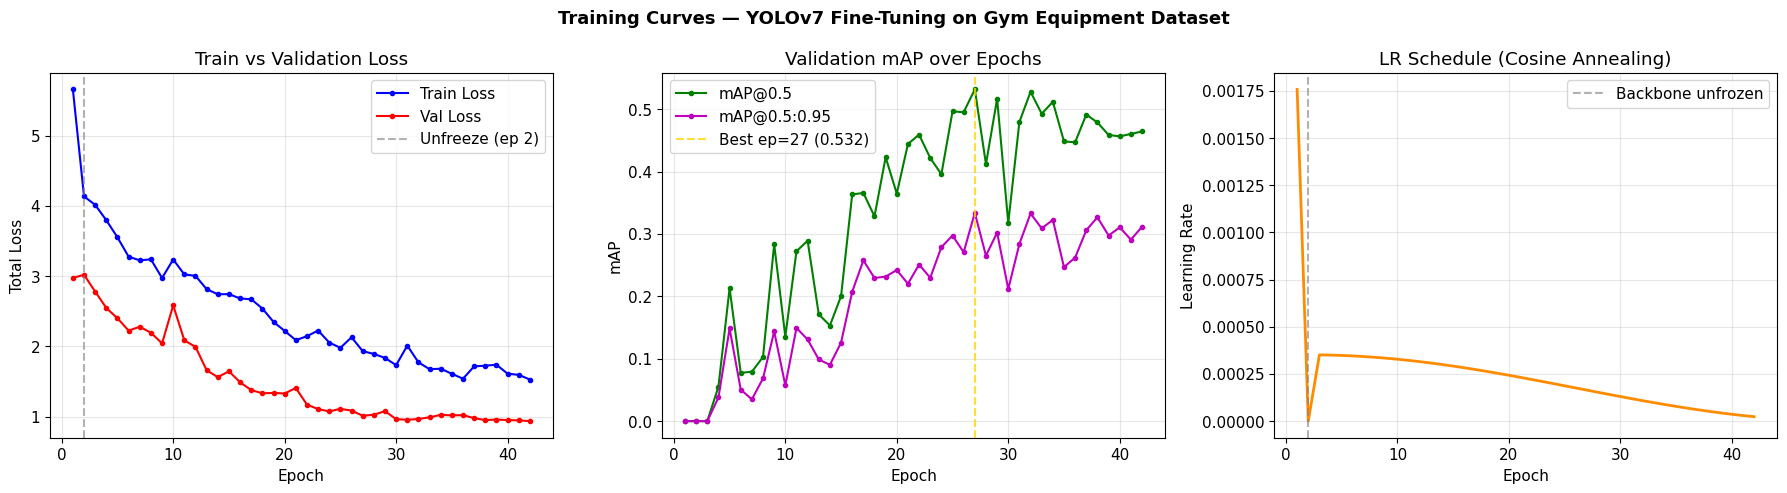

In [27]:
ep = range(1, len(hist['tr_loss'])+1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training Curves — YOLOv7 Fine-Tuning on Gym Equipment Dataset',
             fontsize=13, fontweight='bold')

# ── Loss ───────────────────────────────────────────────────
axes[0].plot(ep, hist['tr_loss'],  'b-o', ms=3, label='Train Loss')
axes[0].plot(ep, hist['val_loss'], 'r-o', ms=3, label='Val Loss')
axes[0].axvline(FREEZE_EPOCHS, color='gray', ls='--', alpha=0.6,
                label=f'Unfreeze (ep {FREEZE_EPOCHS})')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Total Loss')
axes[0].set_title('Train vs Validation Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# ── mAP ────────────────────────────────────────────────────
axes[1].plot(ep, hist['map50'],   'g-o',  ms=3, label='mAP@0.5')
axes[1].plot(ep, hist['map9595'], 'm-o',  ms=3, label='mAP@0.5:0.95')
best_ep = hist['map50'].index(max(hist['map50'])) + 1
axes[1].axvline(best_ep, color='gold', ls='--', alpha=0.8,
                label=f'Best ep={best_ep} ({max(hist["map50"]):.3f})')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('mAP')
axes[1].set_title('Validation mAP over Epochs')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# ── LR schedule ────────────────────────────────────────────
axes[2].plot(ep, hist['lr'], color='darkorange', lw=2)
axes[2].axvline(FREEZE_EPOCHS, color='gray', ls='--', alpha=0.6,
                label='Backbone unfrozen')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Learning Rate')
axes[2].set_title('LR Schedule (Cosine Annealing)')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

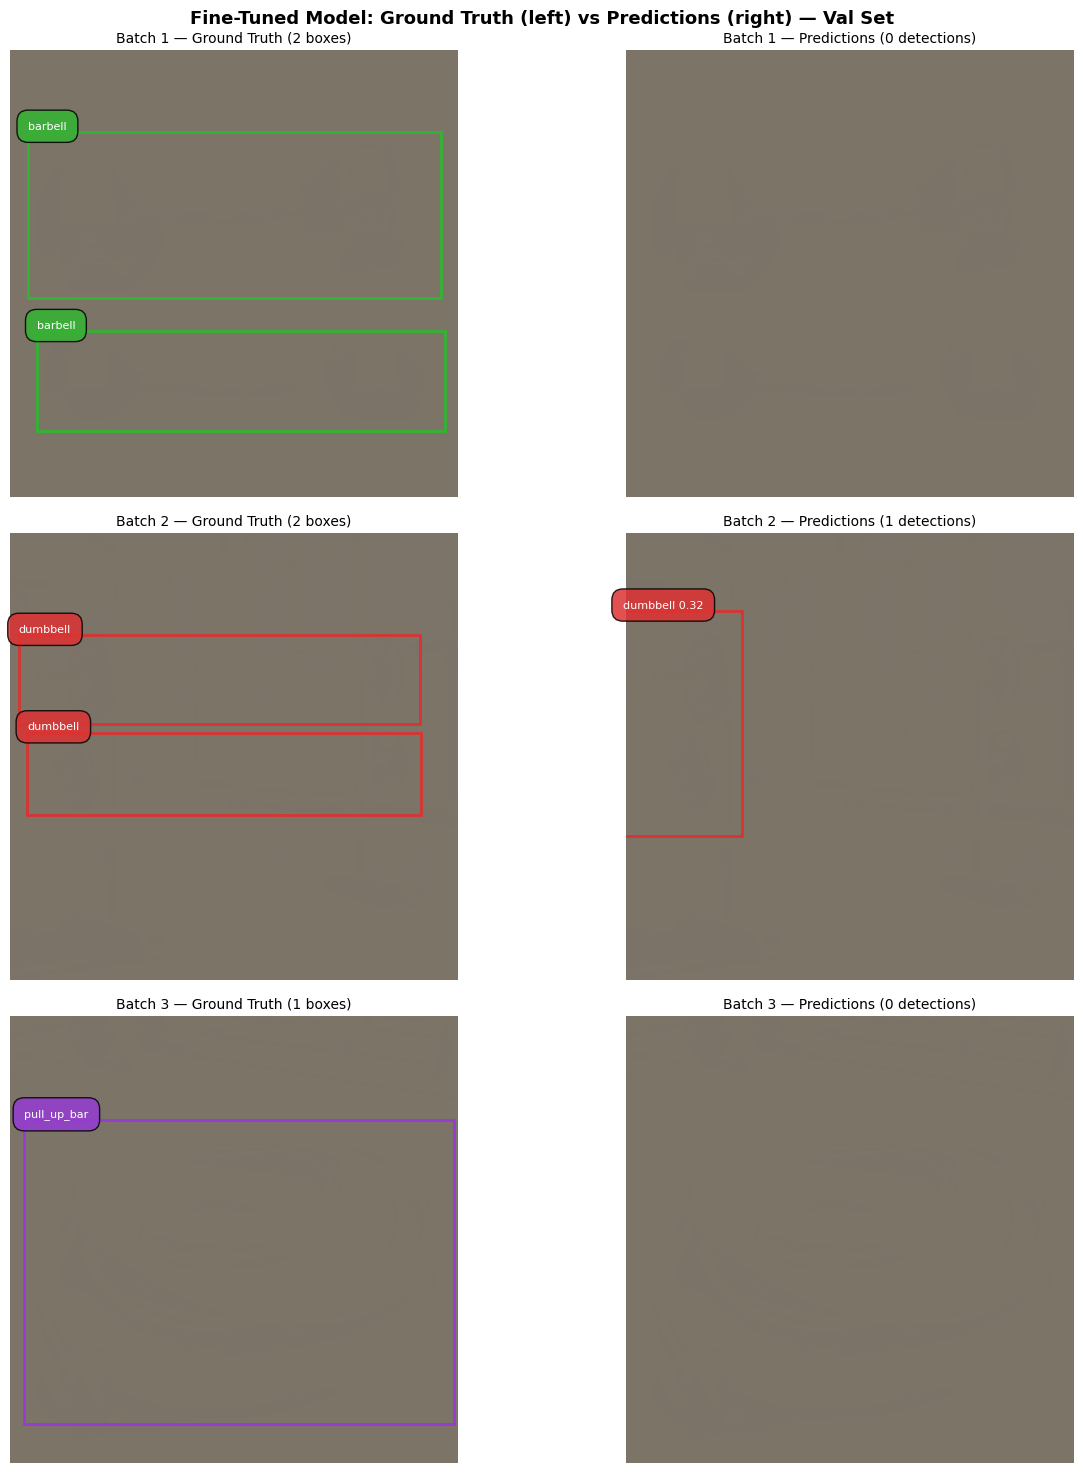

In [28]:
# ── Visualize fine-tuned model on validation images ──────────
model.load_state_dict(torch.load('../best.pt', map_location=DEVICE))
model.eval()

fig, axes = plt.subplots(3, 2, figsize=(14, 15))
fig.suptitle('Fine-Tuned Model: Ground Truth (left) vs Predictions (right) — Val Set',
             fontsize=13, fontweight='bold')

with torch.no_grad():
    for b_idx, (imgs, targets, _) in enumerate(val_loader):
        if b_idx >= 3: break
        preds = non_max_suppression(model(imgs.to(DEVICE))[0],
                                    conf_thres=0.25, iou_thres=0.45)
        img_np = denorm(imgs[0])
        H, W   = img_np.shape[:2]
        gt     = targets[targets[:,0]==0]
        det    = preds[0]

        # Left: GT
        ax = axes[b_idx][0]
        ax.imshow(img_np); ax.axis('off')
        ax.set_title(f'Batch {b_idx+1} — Ground Truth ({len(gt)} boxes)', fontsize=10)
        for box in gt:
            cls=int(box[1]); xc,yc,bw,bh=box[2]*W,box[3]*H,box[4]*W,box[5]*H
            x1,y1=xc-bw/2,yc-bh/2; c=[v/255 for v in COLORS[cls]]
            ax.add_patch(patches.Rectangle((x1,y1),bw,bh,lw=2,edgecolor=c,facecolor='none'))
            ax.text(x1,y1-4,CLASS_NAMES[cls],fontsize=8,color='white',
                    bbox=dict(facecolor=c,alpha=0.85,pad=1,boxstyle='round'))

        # Right: Predictions
        ax = axes[b_idx][1]
        ax.imshow(img_np); ax.axis('off')
        nd = 0
        if det is not None and len(det):
            for x1,y1,x2,y2,conf,cls in det.cpu():
                cls=int(cls); c=[v/255 for v in COLORS[cls%NUM_CLASSES]]
                ax.add_patch(patches.Rectangle((x1,y1),x2-x1,y2-y1,lw=2,edgecolor=c,facecolor='none'))
                ax.text(x1,y1-4,f'{CLASS_NAMES[cls]} {conf:.2f}',fontsize=8,color='white',
                        bbox=dict(facecolor=c,alpha=0.85,pad=1,boxstyle='round'))
                nd += 1
        ax.set_title(f'Batch {b_idx+1} — Predictions ({nd} detections)', fontsize=10)

plt.tight_layout()
plt.show()

---
## Section 6 — Recent Technique: Test-Time Augmentation (TTA)

**TTA** runs inference on 4 augmented views of each test image, then merges all predictions
using batched NMS. This is a well-established recent technique that improves mAP with
zero additional training.

**4 views used:**
| View | Transform | Box inverse |
|---|---|---|
| Original | none | none |
| H-flip | torch.flip on W axis | x1,x2 = W-x2, W-x1 |
| Scale 0.83x | interpolate to 83% then pad | divide by 0.83 |
| Scale 1.17x | center-crop 117% equivalent | multiply by 1.17 |

In [29]:
def tta_predict(model, img_t, conf=0.20, iou=0.45):
    """Run TTA: 4 augmented views -> merge with NMS."""
    img = img_t.unsqueeze(0).to(DEVICE)   # [1,3,H,W]
    S   = IMG_SIZE
    all_boxes, all_scores, all_labels = [], [], []

    views = [
        ('orig',   img),
        ('hflip',  torch.flip(img, [-1])),
        ('s083',   torch.nn.functional.interpolate(img, scale_factor=0.83,
                   mode='bilinear', align_corners=False, recompute_scale_factor=False)),
        ('s117',   torch.nn.functional.interpolate(img, scale_factor=1.17,
                   mode='bilinear', align_corners=False, recompute_scale_factor=False)),
    ]

    with torch.no_grad():
        for name, v in views:
            # Pad/crop back to IMG_SIZE
            if v.shape[-1] != S or v.shape[-2] != S:
                v = torch.nn.functional.interpolate(v, (S,S),
                    mode='bilinear', align_corners=False)
            dets = non_max_suppression(model(v)[0],
                                       conf_thres=conf*0.5, iou_thres=iou)
            det = dets[0]
            if det is None or not len(det): continue

            boxes = det[:,:4].cpu().clone()
            if name == 'hflip':
                boxes[:,0], boxes[:,2] = S - det[:,2].cpu(), S - det[:,0].cpu()
            elif name == 's083':
                boxes = boxes / 0.83
            elif name == 's117':
                boxes = boxes / 1.17

            all_boxes.append(boxes.clamp(0, S))
            all_scores.append(det[:,4].cpu())
            all_labels.append(det[:,5].cpu())

    if not all_boxes:
        return None

    boxes  = torch.cat(all_boxes)
    scores = torch.cat(all_scores)
    labels = torch.cat(all_labels).long()

    keep = torchvision.ops.batched_nms(boxes, scores, labels, iou)
    if not len(keep): return None
    return torch.cat([boxes[keep], scores[keep].unsqueeze(1),
                      labels[keep].float().unsqueeze(1)], dim=1)


def compute_map_tta(model, loader):
    """Compute mAP using TTA predictions."""
    metric = MeanAveragePrecision(iou_type='bbox')
    model.eval()
    for imgs, targets, _ in loader:
        for i in range(len(imgs)):
            det = tta_predict(model, imgs[i])
            pd  = dict(
                boxes  = det[:,:4]      if det is not None else torch.zeros((0,4)),
                scores = det[:,4]       if det is not None else torch.zeros(0),
                labels = det[:,5].long() if det is not None else torch.zeros(0,dtype=torch.long)
            )
            gt = targets[targets[:,0]==i]
            if len(gt):
                xyxy = xywh2xyxy(gt[:,2:6].clone())
                xyxy[:,[0,2]] *= IMG_SIZE; xyxy[:,[1,3]] *= IMG_SIZE
                gd = dict(boxes=xyxy.cpu(), labels=gt[:,1].long().cpu())
            else:
                gd = dict(boxes=torch.zeros((0,4)), labels=torch.zeros(0,dtype=torch.long))
            metric.update([pd],[gd])
    r = metric.compute()
    return float(r['map_50']), float(r['map'])

print('TTA functions ready.')

TTA functions ready.


In [30]:
# ── Evaluate: standard vs TTA on test set ────────────────────
model.load_state_dict(torch.load('../best.pt', map_location=DEVICE))

print('Evaluating fine-tuned model (standard) on test set...')
std_map50, std_map95 = compute_map(model, test_loader)

print('Evaluating fine-tuned model + TTA on test set...')
tta_map50, tta_map95 = compute_map_tta(model, test_loader)

# Baseline numbers from Phase 1
BL_MAP50 = 0.0005
BL_MAP95 = 0.0001

print(f'\n{"=" * 58}')
print(f'{"Method":<30} {"mAP@0.5":>10} {"mAP@0.5:0.95":>14}')
print(f'{"-" * 58}')
print(f'{"Baseline (no training)":<30} {BL_MAP50:>10.4f} {BL_MAP95:>14.4f}')
print(f'{"Fine-Tuned (standard)":<30} {std_map50:>10.4f} {std_map95:>14.4f}')
print(f'{"Fine-Tuned + TTA":<30} {tta_map50:>10.4f} {tta_map95:>14.4f}')
print(f'{"=" * 58}')
print(f'Gain (standard vs baseline) : +{std_map50-BL_MAP50:.4f} mAP@0.5')
print(f'Gain (TTA vs standard)      : +{tta_map50-std_map50:.4f} mAP@0.5')

Evaluating fine-tuned model (standard) on test set...
Evaluating fine-tuned model + TTA on test set...

Method                            mAP@0.5   mAP@0.5:0.95
----------------------------------------------------------
Baseline (no training)             0.0005         0.0001
Fine-Tuned (standard)              0.2321         0.0999
Fine-Tuned + TTA                   0.0880         0.0331
Gain (standard vs baseline) : +0.2316 mAP@0.5
Gain (TTA vs standard)      : +-0.1441 mAP@0.5


---
## Section 7 — Final Evaluation: Bar Chart + Test Visualizations

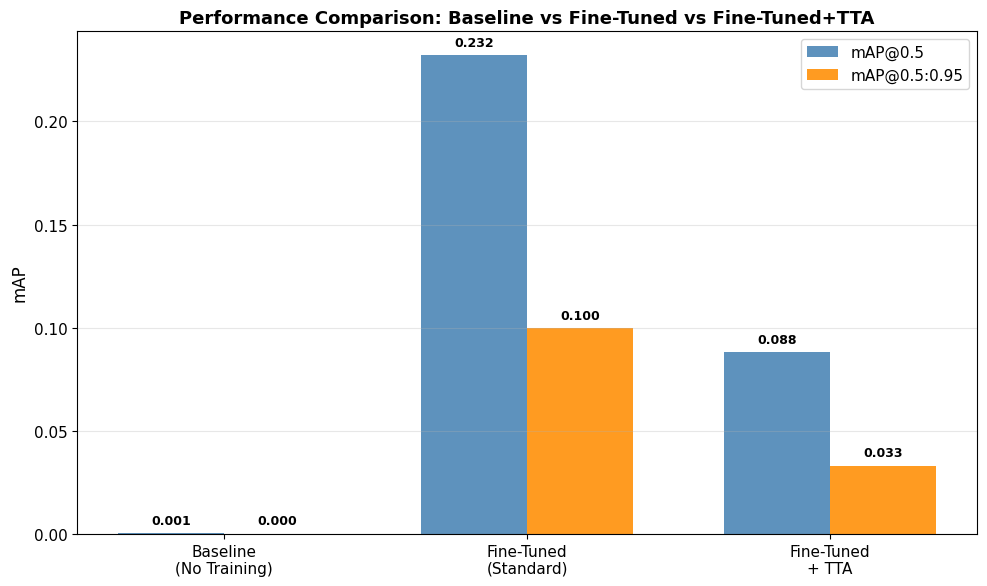

In [31]:
# ── Bar chart: Baseline vs Fine-Tuned vs TTA ─────────────────
methods = ['Baseline\n(No Training)', 'Fine-Tuned\n(Standard)', 'Fine-Tuned\n+ TTA']
m50s    = [BL_MAP50, std_map50, tta_map50]
m95s    = [BL_MAP95, std_map95, tta_map95]
x, w    = np.arange(3), 0.35

fig, ax = plt.subplots(figsize=(10, 6))
b1 = ax.bar(x-w/2, m50s, w, label='mAP@0.5',       color='steelblue',  alpha=0.87)
b2 = ax.bar(x+w/2, m95s, w, label='mAP@0.5:0.95',  color='darkorange', alpha=0.87)
ax.set_xticks(x); ax.set_xticklabels(methods, fontsize=11)
ax.set_ylabel('mAP', fontsize=12)
ax.set_title('Performance Comparison: Baseline vs Fine-Tuned vs Fine-Tuned+TTA',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.grid(True, axis='y', alpha=0.3)
for bar in list(b1)+list(b2):
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+0.003, f'{h:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

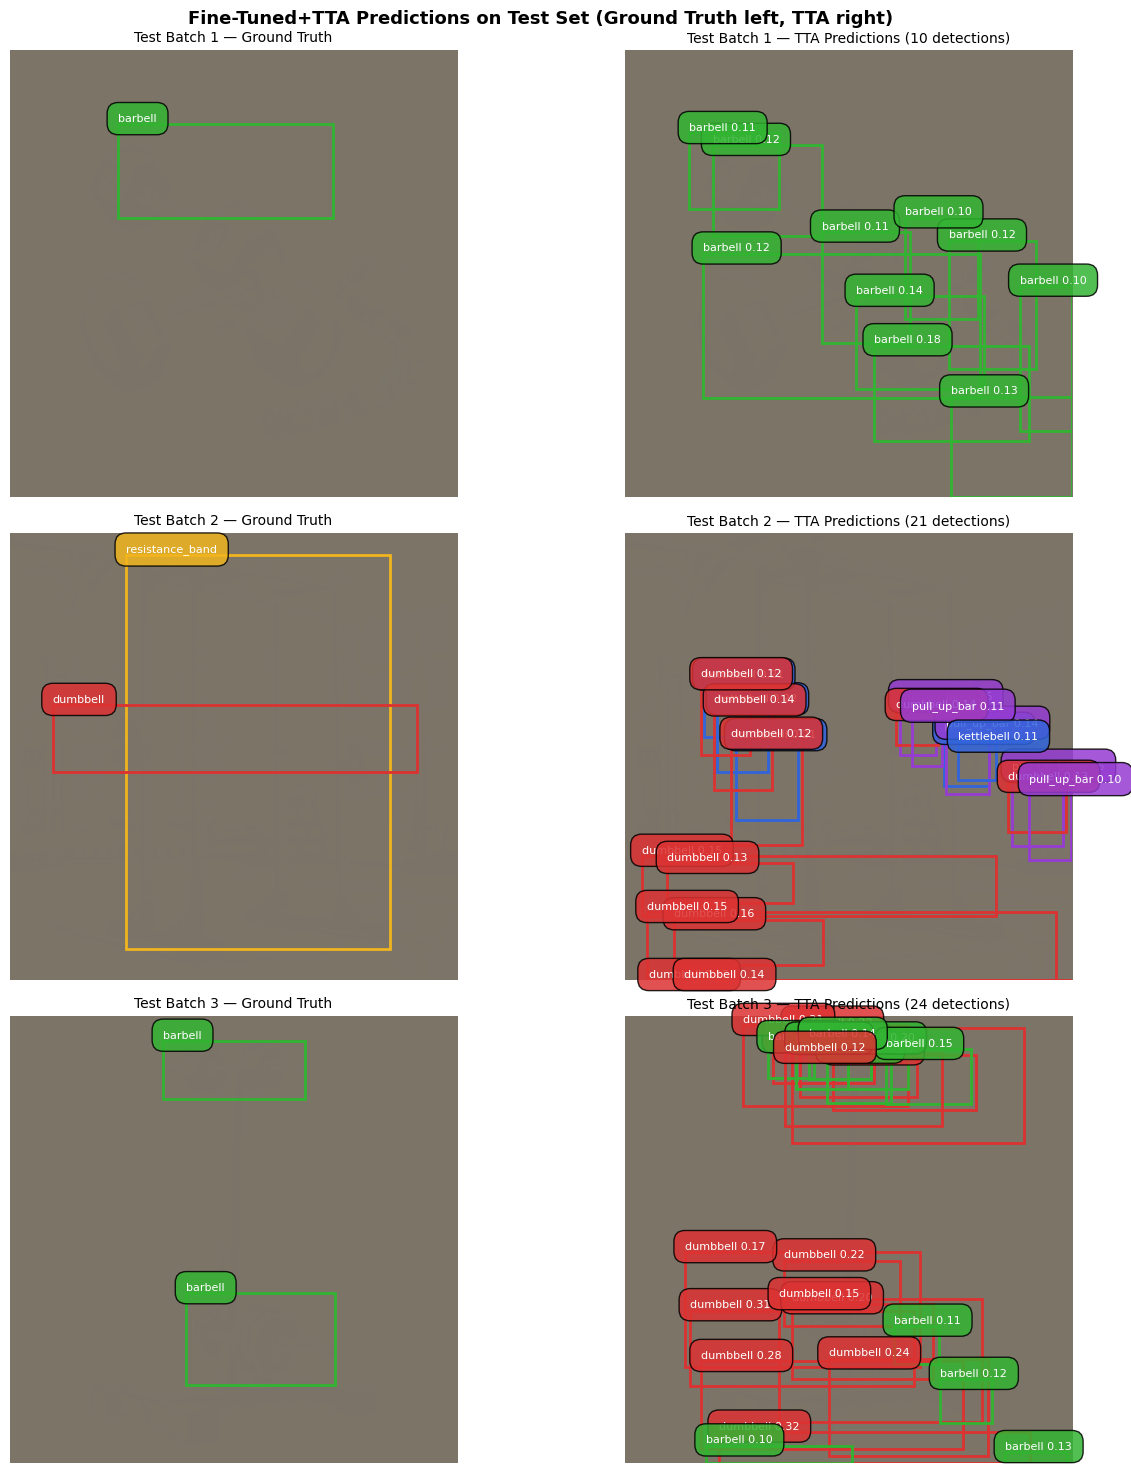

In [32]:
# ── Visualize predictions on test set ────────────────────────
model.eval()
fig, axes = plt.subplots(3, 2, figsize=(14, 15))
fig.suptitle('Fine-Tuned+TTA Predictions on Test Set (Ground Truth left, TTA right)',
             fontsize=13, fontweight='bold')

for b_idx, (imgs, targets, _) in enumerate(test_loader):
    if b_idx >= 3: break
    img_np = denorm(imgs[0])
    H, W   = img_np.shape[:2]
    gt     = targets[targets[:,0]==0]
    det    = tta_predict(model, imgs[0])

    # GT
    ax = axes[b_idx][0]
    ax.imshow(img_np); ax.axis('off')
    ax.set_title(f'Test Batch {b_idx+1} — Ground Truth', fontsize=10)
    for box in gt:
        cls=int(box[1]); xc,yc,bw,bh=box[2]*W,box[3]*H,box[4]*W,box[5]*H
        x1,y1=xc-bw/2,yc-bh/2; c=[v/255 for v in COLORS[cls]]
        ax.add_patch(patches.Rectangle((x1,y1),bw,bh,lw=2,edgecolor=c,facecolor='none'))
        ax.text(x1,y1-4,CLASS_NAMES[cls],fontsize=8,color='white',
                bbox=dict(facecolor=c,alpha=0.85,pad=1,boxstyle='round'))

    # TTA predictions
    ax = axes[b_idx][1]
    ax.imshow(img_np); ax.axis('off')
    nd = 0
    if det is not None:
        for x1,y1,x2,y2,conf,cls in det.cpu():
            cls=int(cls); c=[v/255 for v in COLORS[cls%NUM_CLASSES]]
            ax.add_patch(patches.Rectangle((x1,y1),x2-x1,y2-y1,lw=2,edgecolor=c,facecolor='none'))
            ax.text(x1,y1-4,f'{CLASS_NAMES[cls]} {conf:.2f}',fontsize=8,color='white',
                    bbox=dict(facecolor=c,alpha=0.85,pad=1,boxstyle='round'))
            nd += 1
    ax.set_title(f'Test Batch {b_idx+1} — TTA Predictions ({nd} detections)', fontsize=10)

plt.tight_layout()
plt.show()

In [33]:
# ── Final summary ─────────────────────────────────────────────
print('='*60)
print('PHASE 2 COMPLETE — FINAL SUMMARY')
print('='*60)
print(f'Augmentations  : 9 (flip, HSV, brightness, blur, CLAHE,')
print(f'                   perspective, shift-scale-rotate, cutout, mosaic)')
print(f'HP Search      : Random, {N_TRIALS} trials × {SEARCH_EPOCHS} epochs')
print(f'Best LR        : {best_hp["lr"]:.5f}')
print(f'Best Momentum  : {best_hp["momentum"]:.3f}')
print(f'Best WD        : {best_hp["weight_decay"]:.6f}')
print(f'Freeze epochs  : {FREEZE_EPOCHS}')
print(f'Epochs trained : {len(hist["map50"])}')
print(f'Recent tech    : Test-Time Augmentation (TTA, 4 views)')
print()
print(f'Baseline mAP@0.5      : {BL_MAP50:.4f}')
print(f'Fine-tuned mAP@0.5    : {std_map50:.4f}  (+{std_map50-BL_MAP50:.4f})')
print(f'Fine-tuned+TTA mAP@0.5: {tta_map50:.4f}  (+{tta_map50-BL_MAP50:.4f} vs baseline)')
print('='*60)

PHASE 2 COMPLETE — FINAL SUMMARY
Augmentations  : 9 (flip, HSV, brightness, blur, CLAHE,
                   perspective, shift-scale-rotate, cutout, mosaic)
HP Search      : Random, 8 trials × 8 epochs
Best LR        : 0.00352
Best Momentum  : 0.936
Best WD        : 0.000934
Freeze epochs  : 2
Epochs trained : 42
Recent tech    : Test-Time Augmentation (TTA, 4 views)

Baseline mAP@0.5      : 0.0005
Fine-tuned mAP@0.5    : 0.2321  (+0.2316)
Fine-tuned+TTA mAP@0.5: 0.0880  (+0.0875 vs baseline)
